<a href="https://colab.research.google.com/github/mptorpo/integracion_prospectiva_y_datos/blob/main/Parcial_2_Miguel_Pimiento_Restrepo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial 2**

- Miguel Pimiento Restrepo
- Epik ID: 1000293648

Una entidad del sector FINTECH está interesada en desarrollar un sistema por adaptación y aprendizaje (K-Means) que le permita proyectar, desde la gestión de sus riesgos operacionales, el valor potencial de captura de Gases de Efecto Invernadero (GEI).

Para la gestión de los riesgos, los impactos más frecuentes están asociados con fallas tecnológicas en los canales electrónicos(transacciones fallidas, degradación del rendimiento, caídas de sistema, ciberataques). Es por esto que la organización quiere diseñar una serie de matrices de gestión e impacto que le permitan mitigar los riesgos asociados (Parámetros de Riesgo – Pólizas de Aseguramiento).

Para la construcción de estas matrices se procederá con la clusterización de las variables de frecuencia (número de transacciones fallidas) e impacto (valor generado promedio en millones de USD) utilizando el método K-Means.

**Variables:**
- Fechas: día de reporte del evento (entre enero de 2009 y diciembre de 2011, ~701 registros).
- Transacciones Diarias: volumen total de transacciones procesadas por los canales electrónicos en el día. Mide la exposición operativa de la FINTECH.
- Valor Transado (millones): monto total movilizado ese día en millones de USD. Permite dimensionar la criticidad financiera de la operación diaria.
- Transacciones Fallidas: número de transacciones que presentaron algún tipo de falla tecnológica en el día. Es la variable de frecuencia del riesgo operacional.
- Valor Generado Promedio (Millones): pérdida promedio en millones de USD asociada a las transacciones fallidas del día. Es la variable de severidad del riesgo operacional.
- Descripción Evento: clasificación cualitativa del evento de riesgo, que va desde errores visuales menores hasta caídas totales del sistema o ciberataques.

# **Codigo**

0. Se procede con la carga de las librerías de trabajo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Definimos la función de clusterización que asigna cada observación a uno de cinco niveles de riesgo (Improbable, Posible, Ocasional, Probable, Frecuente) mediante un proceso iterativo tipo K-Means.

In [2]:
def clusterizacion(Xi):

# Proceso de clusterización
  XC = np.random.choice(Xi, size = 5)
  XC = np.sort(XC) # Semillas de la clusterización (Improbable, Posible, Ocasional, Probable, Frecuente)
  nc = np.zeros((len(Xi),1))

  for k in range(len(Xi)): # El primer dato en primera semilla
    d = np.abs(XC-Xi[k]) # Distancia de un dato a cada semilla
    nc[k] = np.argmin(d)
    nc2 = np.int32(nc[k])
    XC[nc2,] = (XC[nc2,]+Xi[k])/2

  return XC,nc

1. Se cargan los archivos de trabajo

Se carga la base de datos de eventos de riesgo asociados con las fallas tecnológicas en los canales electrónicos de la FINTECH. Se aplica la función de clusterización a las variables de frecuencia (transacciones fallidas), severidad (valor generado promedio) y la distribución agregada de pérdidas (LDA = Frecuencia x Severidad).

In [3]:
nxl = '/content/drive/MyDrive/Colab Notebooks/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, sheet_name = 0, header = 1)
XDB.head()

,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [4]:
np.random.seed(42)

# Obtenemos la variable de Frecuencia (Transacciones Fallidas)
Xf = np.array(XDB.iloc[:,3])
XCf, ncf = clusterizacion(Xf)

# Obtenemos la variable de Severidad (Valor Generado Promedio en Millones)
Xs = np.array(XDB.iloc[:,4])
XCs, ncs = clusterizacion(Xs)

# Se procede a determinar la distribución agregada de pérdidas
LDA = Xf*Xs
XClda, nclda = clusterizacion(LDA)

# Creamos un dataframe para descargar
df = pd.DataFrame(np.column_stack((Xf,ncf,Xs,ncs,LDA,nclda,XDB.iloc[:,5])))
df.columns = ['Freq', 'Nivel_f','Sev.','Nivel_S','LDA','Nivel_LDA','Riesgos']
df.head()

,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos
0,1,0.0,0.5374,0.0,0.5374,0.0,"Errores visuales menores, problemas de usabili..."
1,4,0.0,1.1978,2.0,4.7912,2.0,"Errores en la interfaz de usuario, fallas en f..."
2,5,1.0,0.4269,0.0,2.1345,1.0,"Errores visuales menores, problemas de usabili..."
3,6,1.0,1.0814,1.0,6.4884,3.0,"Errores en la interfaz de usuario, fallas en f..."
4,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f..."


2. Procedemos con la construcción de la matriz de eventos de riesgo

Construimos la matriz de eventos de riesgo (frecuencia x impacto) y la matriz de severidad por casilla. Posteriormente se construye la matriz de impacto (MI) y la matriz de gestión (MG).

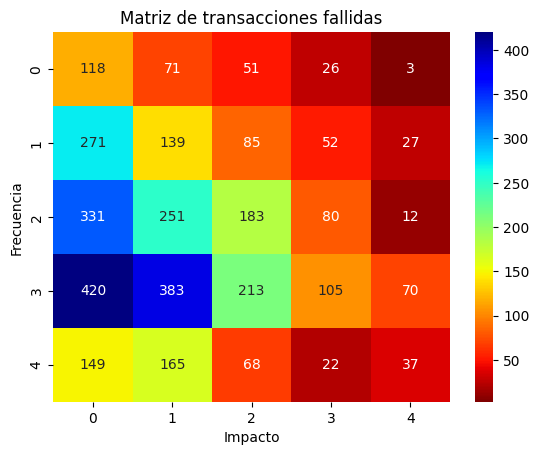

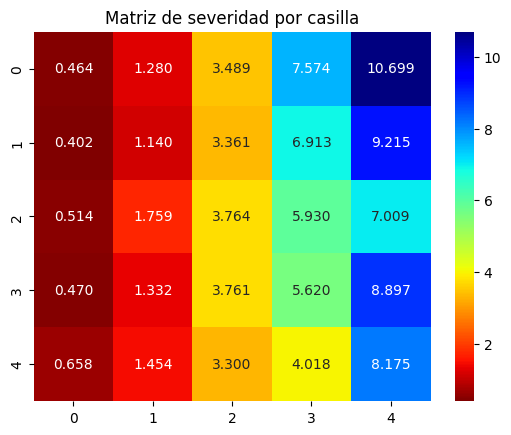

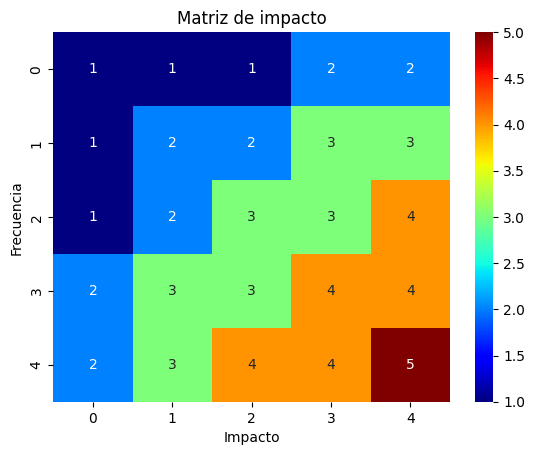

Ingresar el nivel de Gestión (1,2,3,4):2


Text(0.5, 1.0, 'Matriz de gestión (Actividades de gestión)')

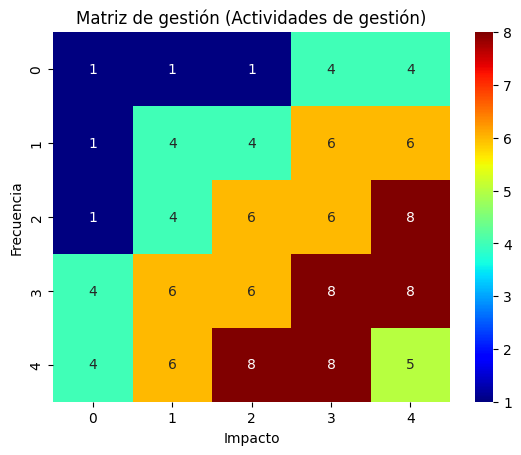

In [5]:
MEf = np.zeros((5,5)) # Cuántas transacciones fallidas se reportaron por categoría de frecuencia y de impacto
MEs = np.zeros((5,5)) # Costo promedio (severidad) por casilla

for k in range(len(Xf)):
   nf = np.int32(df.iloc[k,1]) # Fila de frecuencia
   nc = np.int32(df.iloc[k,3]) # Columna de impacto
   MEf[nf,nc] = MEf[nf,nc]+Xf[k] # Acumulado de transacciones fallidas en la casilla
   MEs[nf,nc] = (MEs[nf,nc]+Xs[k,])/2 # Costo promedio por transacción fallida


plt.figure()
sns.heatmap(MEf,annot=True, fmt='.0f',cmap='jet_r')
plt.xlabel('Impacto')
plt.ylabel('Frecuencia')
plt.title('Matriz de transacciones fallidas')
plt.show()

plt.figure()
sns.heatmap(MEs,annot=True, fmt='.3f',cmap='jet_r')
plt.title('Matriz de severidad por casilla')
plt.show()

# Procedemos con la creación de la matriz de impacto
MI = np.array([[1,1,1,2,2],
             [1,2,2,3,3],
             [1,2,3,3,4],
             [2,3,3,4,4],
             [2,3,4,4,5]])

plt.figure()
sns.heatmap(MI,annot=True, fmt='.0f',cmap='jet')
plt.xlabel('Impacto')
plt.ylabel('Frecuencia')
plt.title('Matriz de impacto')
plt.show()


# Matriz de gestión - Involucra recursos de la organización
NG = np.int32(input("Ingresar el nivel de Gestión (1,2,3,4):"))
MG = np.copy(MI)
for i in range(5): # Si es mayor que 1 y menor que 5, incrementa la gestión
  for j in range(5):
    if MG[i,j]>1 and MG[i,j]<5:
      MG[i,j] = MG[i,j]*NG


plt.figure()
sns.heatmap(MG,annot=True, fmt='.0f',cmap='jet')
plt.xlabel('Impacto')
plt.ylabel('Frecuencia')
plt.title('Matriz de gestión (Actividades de gestión)')

In [6]:
# 1. Pérdida esperada (promedio simple)
ps = np.mean(MEs)
print("El promedio simple de severidad por atender una transacción fallida es:", ps)

# 2. Como no todos los eventos tienen la misma frecuencia
# Hay pocos eventos que sufren pérdidas extremas
pp = np.round(np.sum(MEf*MEs)/np.sum(MEf),3)
print("El promedio ponderado de severidad por atender una transacción fallida es:",pp,"millones USD")

# 3. Se procede a determinar la pérdida ponderada teniendo en cuenta la matriz de impacto - Nivel de riesgo
pnr = np.sum(MEf*MEs*MI)/np.sum(MEf*MI)
print("El promedio ponderado de severidad teniendo en cuenta el nivel de riesgo es:",pnr,"millones USD")

# 4. Se procede a determinar la pérdida ponderada teniendo en cuenta la matriz de gestión
png = np.sum(MEf*MEs*MI)/np.sum(MEf*MG)
print(f"El promedio ponderado de severidad teniendo en cuenta un nivel de gestión {NG} es:",png,"millones USD")

El promedio simple de severidad por atender una transacción fallida es: 4.047830871818241
El promedio ponderado de severidad por atender una transacción fallida es: 2.175 millones USD
El promedio ponderado de severidad teniendo en cuenta el nivel de riesgo es: 2.8118425171752874 millones USD
El promedio ponderado de severidad teniendo en cuenta un nivel de gestión 2 es: 1.5079406984639605 millones USD


In [7]:
fila = np.int32(input("Ingresar el nivel de frecuencia:"))
columna = np.int32(input("Ingresar el nivel de impacto:"))
df[(df.iloc[:,1]==fila)&(df.iloc[:,3]==columna)]

Ingresar el nivel de frecuencia:2
Ingresar el nivel de impacto:2


,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos
4,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f..."
23,5,2.0,1.3368,2.0,6.684,2.0,"Errores en la interfaz de usuario, fallas en f..."
44,6,2.0,1.2693,2.0,7.6158,2.0,"Errores en la interfaz de usuario, fallas en f..."
67,5,2.0,1.6576,2.0,8.288,1.0,"Errores en la interfaz de usuario, fallas en f..."
82,5,2.0,1.5423,2.0,7.7115,2.0,"Errores en la interfaz de usuario, fallas en f..."
110,6,2.0,1.6892,2.0,10.1352,2.0,"Errores en la interfaz de usuario, fallas en f..."
115,5,2.0,1.9072,2.0,9.536,2.0,"Errores en la interfaz de usuario, fallas en f..."
143,6,2.0,2.1317,2.0,12.7902,2.0,"Errores en la interfaz de usuario, fallas en f..."
157,6,2.0,2.6077,2.0,15.6462,2.0,"Degradación del rendimiento por varias horas, ..."
191,5,2.0,2.2048,2.0,11.024,2.0,"Errores en la interfaz de usuario, fallas en f..."


3. Se procederá con la caracterización de la distribución agregada de las pérdidas (LDA: Loss Distribution Approach) y sus parámetros de riesgo. Los parámetros de riesgo generalmente son 3:
- **C1: Pérdidas Esperadas** (Pérdidas Menores: errores visuales, problemas de usabilidad, notificaciones falsas).
- **C2: Pérdidas No Esperadas** (Pérdidas Gestionables: degradación del rendimiento, interrupciones temporales).
- **C3: Pérdidas Catastróficas** (Caída total del sistema, ciberataques, pérdida masiva de datos).

In [8]:
# Se procede con la gráfica de la distribución de pérdidas (LDA)
LDA = np.array(df.iloc[:,4])
LC1 = np.mean(LDA); print("El límite de las Pérdidas Esperadas (C1) es:", LC1)
OpVar = np.percentile(LDA, 99.9); print("El límite Inferior de las Pérdidas C3 es:", OpVar)

# Contabilizamos el número de transacciones fallidas por categoría de riesgo
nc_c1 = np.sum(df[df.iloc[:,4]<LC1].iloc[:,0])
print("El número de transacciones fallidas con pérdidas menores a C1 son:", nc_c1)
nc_c3 = np.sum(df[df.iloc[:,4]>OpVar].iloc[:,0])
print("El número de transacciones fallidas con pérdidas mayores al OpVar:", nc_c3)
nc_c2 = np.sum(df.iloc[:,0])-nc_c1-nc_c3
print("El número de transacciones fallidas con pérdidas gestionables C2 son:", nc_c2)

# Los valores porcentuales del riesgo son:
print("El porcentaje de eventos de riesgo C1 es:", nc_c1/np.sum(df.iloc[:,0]))
print("El porcentaje de eventos de riesgo C2 es:", nc_c2/np.sum(df.iloc[:,0]))
print("El porcentaje de eventos de riesgo C3 es:", nc_c3/np.sum(df.iloc[:,0]))

El límite de las Pérdidas Esperadas (C1) es: 9.45111269614836
El límite Inferior de las Pérdidas C3 es: 102.9021000000008
El número de transacciones fallidas con pérdidas menores a C1 son: 1952
El número de transacciones fallidas con pérdidas mayores al OpVar: 10
El número de transacciones fallidas con pérdidas gestionables C2 son: 1370
El porcentaje de eventos de riesgo C1 es: 0.5858343337334934
El porcentaje de eventos de riesgo C2 es: 0.41116446578631455
El porcentaje de eventos de riesgo C3 es: 0.003001200480192077


Me puedes ingresar el nivel de gestión [1, 2, 3, 4, 5]: 2
El número de transacciones fallidas en C1 luego de una gestión 2 es: 2652
El número de transacciones fallidas en C3 luego de una gestión 2 es: 0
El número de transacciones fallidas en C2 luego de una gestión 2 es: 670
El número de transacciones que migran de C2-C1 son: 700
La Pérdida Promedio (Catastrófica) es: 15.548620000000172
El costo de la Gestión de una Unidad (Transacción) es: 0.012170914647370606
El valor capturado financiero es: 10866.994719493801
El número de toneladas de GEI por año: 72.44663146329201


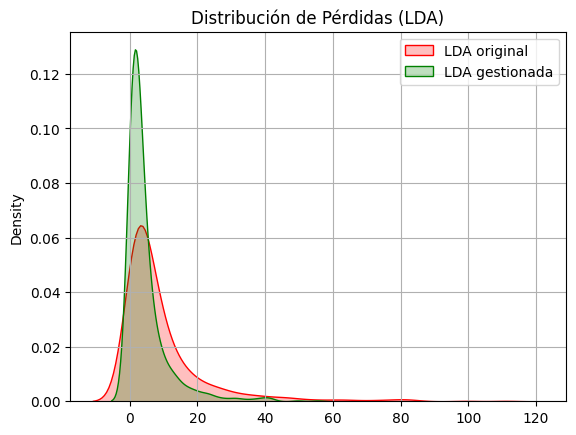

In [9]:
# Gestión de Riesgos - Captura GEI (Gases Efecto Invernadero)
nimp = np.array(df.iloc[:,5]+1)
ngest = np.int32(input("Me puedes ingresar el nivel de gestión [1, 2, 3, 4, 5]: "))
ng2 = nimp*ngest
df['Nivel_LDA'] = nimp
df['Nivel Gestión'] = ng2

# Se procede a determinar la distribución de pérdidas gestionadas
LDA_G = LDA*(nimp/ng2)
df['LDA_Gestionada'] = LDA_G

# Procedemos a contar las transacciones fallidas por categoría luego de la gestión
nc_c1_g = np.sum(df[LDA_G < LC1].iloc[:,0])
print(f"El número de transacciones fallidas en C1 luego de una gestión {ngest} es: {nc_c1_g}")
nc_c3_g = np.sum(df[LDA_G > OpVar].iloc[:,0])
print(f"El número de transacciones fallidas en C3 luego de una gestión {ngest} es: {nc_c3_g}")
nc_c2_g = np.sum(df.iloc[:,0])-nc_c1_g-nc_c3
print(f"El número de transacciones fallidas en C2 luego de una gestión {ngest} es: {nc_c2_g}")

# Valor Capturado Financiero
ncg = nc_c1_g - nc_c1
print("El número de transacciones que migran de C2-C1 son:", ncg)
PProm = np.percentile(Xs, 99.9) # Pérdida máxima por evento (catastrófica)
CGest = 0.012170914647370606 # Costo Gestión Nivel 1 - Hoja Gestión (KUSD)
VCapt = ncg*(PProm - (CGest*ngest)) # Valor Capturado - Evito que las transacciones sean C3
print("La Pérdida Promedio (Catastrófica) es:", PProm)
print("El costo de la Gestión de una Unidad (Transacción) es:", CGest)
print("El valor capturado financiero es:", VCapt)
TGEI = 150 # Lo que se paga por tonelada capturada de GEI (Gases Efecto Invernadero)
TCaptGEI = VCapt/TGEI
print("El número de toneladas de GEI por año:", TCaptGEI)

# Gráfica
plt.figure()
sns.kdeplot(LDA, fill = True, color = 'Red', label = 'LDA original')
sns.kdeplot(LDA_G, fill = True, color = 'Green', label = 'LDA gestionada')
plt.title("Distribución de Pérdidas (LDA)")
plt.legend()
plt.grid()
plt.show()

**Análisis de Resultados**

La caracterización inicial de la distribución agregada de pérdidas (LDA) muestra que de las 3.332 transacciones fallidas registradas durante el periodo de análisis, el 58,58% (1.952 transacciones) se concentra por debajo del límite de pérdidas esperadas C1 (9,45 USD), el 41,12% (1.370 transacciones) corresponde a pérdidas no esperadas C2 entre 9,45 y 102,90 USD, y solo el 0,30% (10 transacciones) supera el OpVar al 99,9% y se clasifica como pérdida catastrófica C3. Esta concentración es coherente con un perfil de riesgo operacional típico de una FINTECH, donde la mayoría de las fallas son menores (errores de interfaz, problemas de usabilidad, notificaciones falsas) pero existe una cola larga de eventos críticos (caídas totales del sistema, ciberataques, pérdida masiva de datos) que, a pesar de su baja frecuencia, concentran el mayor potencial de daño financiero por evento.

La lectura conjunta de la matriz de transacciones fallidas y la matriz de severidad por casilla refuerza este diagnóstico. La masa de eventos se acumula en las casillas de frecuencia media-alta y bajo impacto (las celdas (3,0) y (3,1) agrupan 803 transacciones), pero el costo unitario más alto se ubica en la esquina superior derecha de la matriz de severidad —10,70 millones USD por evento en (0,4)—. Esto indica que, si bien la operación cotidiana se ve afectada por fallas frecuentes y baratas, la verdadera exposición financiera se concentra en eventos infrecuentes pero severos, lo que justifica la priorización de la gestión hacia los niveles superiores de impacto en lugar de hacia los volúmenes de eventos menores. El cálculo de pérdidas promedio confirma este efecto: el promedio simple de severidad (4,05 millones USD) se reduce a 2,18 millones USD al ponderar por frecuencia, pero se incrementa nuevamente a 2,81 millones USD al introducir la matriz de impacto, evidenciando que las casillas de mayor riesgo arrastran el costo esperado del portafolio de transacciones.

Al aplicar un nivel de gestión 2 sobre la matriz de impacto, la pérdida ponderada cae de 2,81 a 1,51 millones USD (una reducción cercana al 46%) y la distribución agregada se reconfigura de forma significativa. El número de transacciones en la categoría C1 pasa de 1.952 a 2.652, las transacciones C2 se reducen de 1.370 a 670, y las pérdidas catastróficas C3 caen de 10 a 0. Es decir, 700 transacciones que originalmente se ubicaban en la zona de pérdidas no esperadas migran hacia la zona de pérdidas esperadas como resultado directo de la intervención prospectiva, y los 10 eventos catastróficos previamente identificados son neutralizados. La gráfica de densidad de la LDA original frente a la LDA gestionada visualiza este desplazamiento: la curva verde se concentra y se eleva alrededor del rango de pérdidas menores, mientras que la cola pesada de la curva roja se aplana, indicando una reducción material de la exposición a eventos extremos.

- **Respuesta al objetivo del caso de estudio:** La cuantificación financiera y ambiental de esta gestión prospectiva es el núcleo del sistema solicitado por la FINTECH. Las 700 transacciones que migran de C2 a C1 representan, sobre una pérdida promedio catastrófica de referencia de 15,55 millones USD por evento y un costo de gestión por unidad de 0,01217 KUSD multiplicado por el nivel de gestión, un Valor Capturado Financiero de 10.866,99 USD. Al traducir este valor mediante el precio internacional de referencia de la tonelada de carbono (150 USD por tonelada de CO2), se obtiene un potencial de captura de 72,45 toneladas de GEI por año atribuibles exclusivamente a la gestión prospectiva del riesgo tecnológico en los canales electrónicos. Este resultado es la respuesta operativa al objetivo planteado: el sistema permite a la FINTECH expresar su esfuerzo de mitigación de riesgos no solo como ahorro contable, sino como un equivalente cuantitativo en toneladas de CO2 evitadas, alineando la gestión del riesgo operacional con los marcos ESG y de reporte climático que están adoptando crecientemente las entidades del sector financiero a nivel global.

Desde una perspectiva de sistema prospectivo, los niveles de gestión 1 a 5 actúan como escenarios hipotéticos que la organización puede simular antes de comprometer recursos. El nivel 2 analizado representa una intervención moderada (gestión de configuración, automatización de pruebas, monitoreo de métricas de calidad) con un costo marginal acotado y un retorno claro tanto en reducción de pérdidas no esperadas como en captura ambiental. Niveles superiores de gestión incrementarían el potencial de captura de GEI de forma no lineal, pero también el costo de implementación, lo que convierte el modelo en una herramienta de decisión: la FINTECH puede, para cada nivel de gestión propuesto, calcular el trade-off entre inversión en gestión, valor financiero capturado y toneladas de CO2 equivalentes evitadas, y seleccionar el escenario que maximice el indicador combinado de eficiencia operacional y sostenibilidad.